# Categorical Cross Entropy

In [29]:
import cv2
from urllib.request import urlopen
from PIL import Image
import IPython
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd, numpy as np
from keras.datasets import mnist, fashion_mnist
import random
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.losses import CategoricalCrossentropy,SparseCategoricalCrossentropy,BinaryCrossentropy
from sklearn.datasets import make_blobs
from mlxtend.plotting import plot_decision_regions
import tensorflow as tf
print(tf.__version__)
from sklearn import preprocessing
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

2.21.0


Categorical cross entropy is a widely used cost or loss function in ML. It uses the following ingredients to classify the distance from the desired distribution:
- Logits -> Proportional to probabilities, weigths for each of the output probabilities
- One-hot encoding -> Manner of encoding such that there is only one value in a property vector. For example, the categories [Small, Medium, Large] can be encoded as [(1, 0, 0), (0, 1, 0), (0, 0, 1)]
- Softmax -> Normalisation function for converting logits to probabilities.
- Cross-Entropy -> A measure of how far the output is from the actual label. The goal is to minimize this quantity.

The probabilities coming from the model are values between 0 and 1, which signify which of the one-hot encoded classes are most likely for the given input. In the perfect case these values should match up exactly, but this is never possible. The highest probability value is generally chosen as the result. This can be a value of 0.99, signifying a large degree of certainty, or a lower value signifying a lower certainty. Cross entropy measures how far the prediction is from the real result and is then used in backpropagation to update the model weights.

In [30]:
## Helper functions for data generation
def generate_multiclass_blobs(num_samples_total, training_split, cluster_centers, num_classes, loss_function_used):
    X, targets = make_blobs(n_samples = num_samples_total, centers = cluster_centers, n_features = num_classes, center_box=(0, 1), cluster_std = 1.5)
    categorical_targets = to_categorical(targets)
    X_training = X[training_split:, :]
    X_testing = X[:training_split, :]
    Targets_training = categorical_targets[training_split:]
    Targets_testing = categorical_targets[:training_split].astype(np.int32)
    return X_training, Targets_training, X_testing, Targets_testing


def generate_binary_blobs(num_samples_total, training_split, loss_function_used):
    X, targets = make_blobs(n_samples = num_samples_total, centers = [(0,0), (15,15)], n_features = 2, center_box=(0, 1), cluster_std = 2.5)
    targets[np.where(targets == 0)] = -1
    X_training = X[training_split:, :]
    X_testing = X[:training_split, :]
    Targets_training = targets[training_split:]
    Targets_testing = targets[:training_split]
    return X_training, Targets_training, X_testing, Targets_testing

## Binary Classification

For binary classification there are only two output labels. For this we only need a single output node which outputs a value between 0 and 1, corresponding to each of the two output labels. Closer to 0 means more certain that the input belongs to class 0, more towards 1 means that the input is more certain to belong to class 1.

Below we generate example data to illustrate this concept.

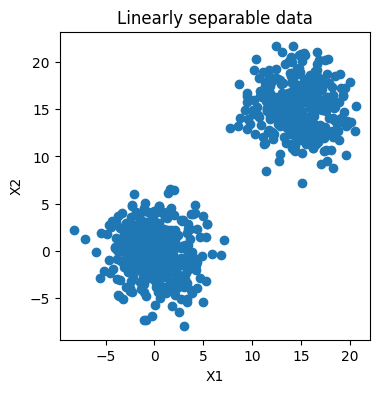

In [31]:
num_samples = 1000
test_split = 250
cluster_centers = [(15,0), (30,15)]
num_classes = len(cluster_centers)
loss_function_used = BinaryCrossentropy(from_logits=False)

X_training, Targets_training, X_testing, Targets_testing = generate_binary_blobs(num_samples, test_split, loss_function_used)

plt.figure(figsize=(4, 4))
plt.scatter(X_training[:,0], X_training[:,1])
plt.title('Linearly separable data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Create a simple NN with 2 hidden layers. The activation function is a Relu for the hidden layers and a sigmoid for the final output layer. We'll use binary cross entropy (defined above) as the loss function.

In [32]:
feature_vector_shape = X_training.shape[1]
input_shape = (feature_vector_shape,)

model = Sequential()
model.add(Input(input_shape))
model.add(Dense(12, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(8, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(1, activation = 'sigmoid'))

model.compile(loss=loss_function_used, optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), metrics=['accuracy'])
history = model.fit(X_training, Targets_training, epochs=30, batch_size=5, verbose=1, validation_split=0.2)

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4617 - loss: -11837.6309 - val_accuracy: 0.4667 - val_loss: -63504.6719
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4800 - loss: -429835.0312 - val_accuracy: 0.4667 - val_loss: -1002911.8750
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4817 - loss: -2414193.2500 - val_accuracy: 0.4667 - val_loss: -3956169.7500
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4767 - loss: -7276741.0000 - val_accuracy: 0.4667 - val_loss: -10094321.0000
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4867 - loss: -16131533.0000 - val_accuracy: 0.4667 - val_loss: -20573822.0000
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4867 - loss: -29906146.0000 - val_accuracy: 0.4600 - val_loss: -35663536.0000
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4867 - loss: -49484024.0000 - val_accuracy: 0.4600 - val_loss: -56761852.0000
Epoc

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5480 - loss: -2721442304.0000  
Test results - Loss: -2721442304.0 - Accuracy: 54.79999780654907%
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 9s 759us/step


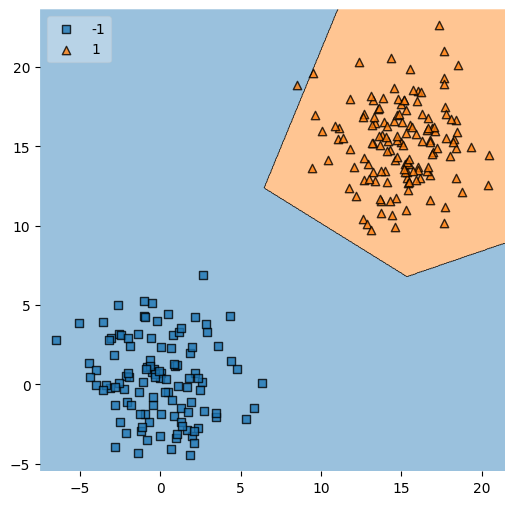

<Figure size 400x400 with 0 Axes>

In [33]:
test_results = model.evaluate(X_testing, Targets_testing, verbose=1)
print(f'Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]*100}%')

plot_decision_regions(X_testing, Targets_testing, clf=model, legend=2)
plt.figure(figsize=(4, 4))
plt.show()

So we can clearly see that the model segments the clusters nicely with a decision boundary.

## Multi-Class Classification

For multiple classes we can set up a similar configuration. Again, we generate some data, this time 3 clusters that are clearly linearly separable.

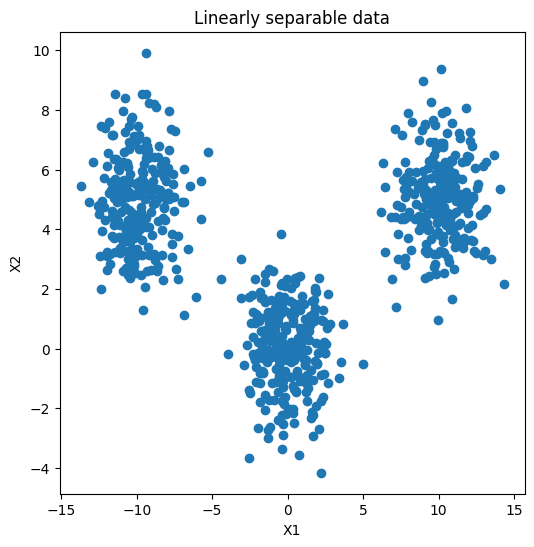

In [34]:
num_samples = 1000
train_split = 250
cluster_centers = [(-10, 5), (0, 0), (10, 5)]
num_classes = len(cluster_centers)
loss_function_used = CategoricalCrossentropy(from_logits=False)

X_training, Targets_training, X_testing, Targets_testing= generate_multiclass_blobs(num_samples, train_split,
              cluster_centers, num_classes,
              loss_function_used)

plt.scatter(X_training[:,0], X_training[:,1])
plt.title('Linearly separable data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

And we can set up a similar NN

In [35]:
feature_vector_shape = X_training.shape[1]
input_shape = (feature_vector_shape,)

model = Sequential()
model.add(Input(input_shape))
model.add(Dense(12, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(8, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=loss_function_used, optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=['accuracy'])
history = model.fit(X_training, Targets_training, epochs=30, batch_size=5, verbose=1, validation_split=0.2)

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5800 - loss: 1.1255 - val_accuracy: 0.8533 - val_loss: 0.4133
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8617 - loss: 0.3692 - val_accuracy: 0.9467 - val_loss: 0.2562
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9067 - loss: 0.2618 - val_accuracy: 0.9533 - val_loss: 0.1927
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9400 - loss: 0.2028 - val_accuracy: 0.9733 - val_loss: 0.1535
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9650 - loss: 0.1611 - val_accuracy: 0.9800 - val_loss: 0.1181
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9883 - loss: 0.1275 - val_accuracy: 0.9867 - val_loss: 0.0947
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9917 - loss: 0.1035 - val_accuracy: 0.9867 - val_loss: 0.0774
Epoch 8/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9933 - loss: 0.0856 - val_accuracy: 1.

Where again we can test the model performance as follows:

In [36]:
test_results = model.evaluate(X_testing, Targets_testing, verbose=1)
print(f'Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]*100}%')

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0054  
Test results - Loss: 0.005414785351604223 - Accuracy: 100.0%


For visualising the results, we need to wrap the model in a compatible class. This is because the `plot_decision_boundary` function expects consecutively labeled class outputs as integers. And the one-hot encoded outputs would not be recognised.

11250/11250 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step


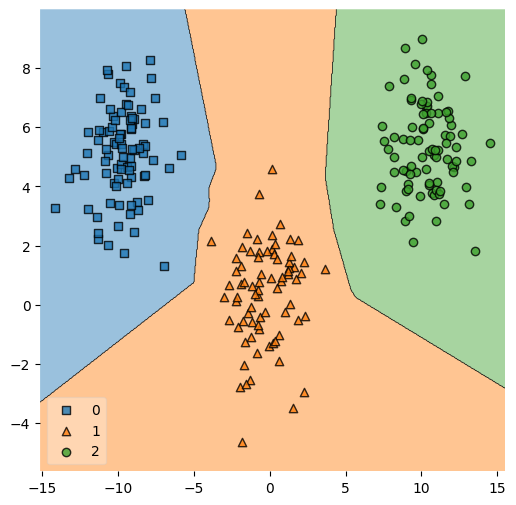

In [37]:
class Onehot2Int(object):

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        y_pred = self.model.predict(X)
        return np.argmax(y_pred, axis=1)

# fit keras_model
keras_model_no_ohe = Onehot2Int(model)

# Plot decision boundary
plot_decision_regions(X_testing, np.argmax(Targets_testing, axis=1), clf=keras_model_no_ohe, legend=3)
plt.show()

## MNIST hand-written digits

Let's now apply this to a real dataset: the MNIST hand-written digits dataset.

In [42]:
(X_train, y_train), (X_test, y_test) = mnist.load_data() 
print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

X_train shape (60000, 28, 28)
y_train shape (60000,)
X_test shape (10000, 28, 28)
y_test shape (10000,)


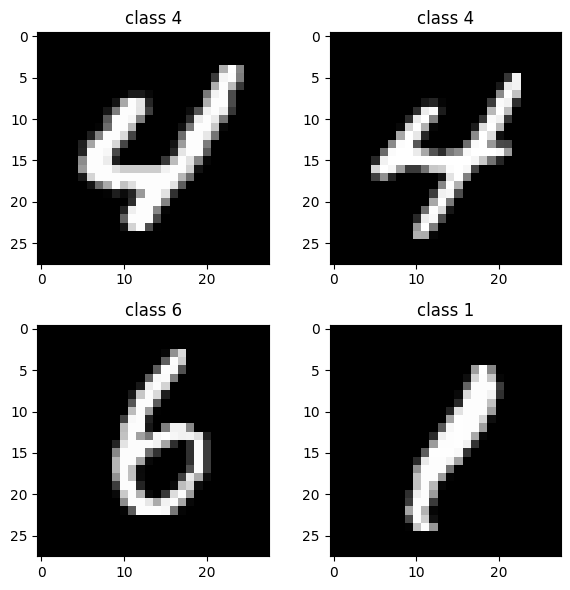

In [43]:
plt.rcParams['figure.figsize'] = (6,6) 

for i in range(4):
    plt.subplot(2,2,i+1)
    num = random.randint(0, len(X_train))
    plt.imshow(X_train[num], cmap='gray', interpolation='none')
    plt.title("class {}".format(y_train[num]))
    
plt.tight_layout()

The input to the network will be a single line vector of all the pixels. So we'll need to reshaps the data into a (28*28)=784 element vector. Then we convert the integer valued bytes (0-255) into floating point values between 0 and 1.

In [44]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1]* X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1] * X_test.shape[2])

print(X_train.shape)
print(X_test.shape)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train /= 255
X_test /= 255

(60000, 784)
(10000, 784)


The `y_train` variable is a long list of class labels corresponding to which number is shown in the image. So the values will be 0-9. This can easily be one-hot encoded by using the `OneHotEncoder` from sklearn.

In [47]:
enc = OneHotEncoder(sparse_output=False)
enc.fit(y_train.reshape(-1, 1))
print(enc.categories_)
y_train_enc = enc.transform(y_train.reshape(-1,1))
y_test_enc = enc.transform(y_test.reshape(-1,1))

[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)]


Now we can build a simple model that will classify the images.  We'll use CategoricalCrossEntropy as out loss function on the softmaxed output over the logits. This is exactly the same model as before, with 2 hidden layers with Relu activation, leading to a single Dense output layer with an output neuron for each class. In this case there will be 10 output neurons instead of 3.

In [50]:
feature_vector_shape = X_train.shape[1]
input_shape = (feature_vector_shape,)
num_classes = 10
loss_function_used=CategoricalCrossentropy(from_logits=False)

model = Sequential()
model.add(Input(input_shape))
model.add(Dense(12, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(8, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=loss_function_used, optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=['accuracy'])
history = model.fit(X_train, y_train_enc, epochs=25, batch_size=5, verbose=1, validation_split=0.2)

test_results = model.evaluate(X_test, y_test_enc, verbose=1)
print(f'Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]*100}%')

Epoch 1/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.8507 - loss: 0.5027 - val_accuracy: 0.9147 - val_loss: 0.3013
Epoch 2/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9131 - loss: 0.2968 - val_accuracy: 0.9273 - val_loss: 0.2466
Epoch 3/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9259 - loss: 0.2518 - val_accuracy: 0.9290 - val_loss: 0.2426
Epoch 4/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9325 - loss: 0.2298 - val_accuracy: 0.9339 - val_loss: 0.2335
Epoch 5/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9362 - loss: 0.2160 - val_accuracy: 0.9397 - val_loss: 0.2105
Epoch 6/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9388 - loss: 0.2060 - val_accuracy: 0.9403 - val_loss: 0.2089
Epoch 7/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 0.9414 - loss: 0.1996 - val_accuracy: 0.9426 - val_loss: 0.1947
Epoch 8/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9427 - loss: 0

## Single-digit House number recognition

Recognising multi digit house numbers is a difficult problem. Simply segmenting the image into separete digits can already be hard to solve in general. Therefore we limit ourselves to a sub problem: classifying single digit house numbers.

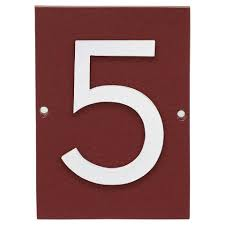

In [52]:
URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/house_number_5.jpeg'
image = Image.open(urlopen(URL)).convert('RGB')
image

We can again the architecture from our previous attempts, the model will be exactly the same so we only need to convert our input into a format the model understands. This means grayscale, 28*28 pixels images, reshaped into a 784 element feature vector. 

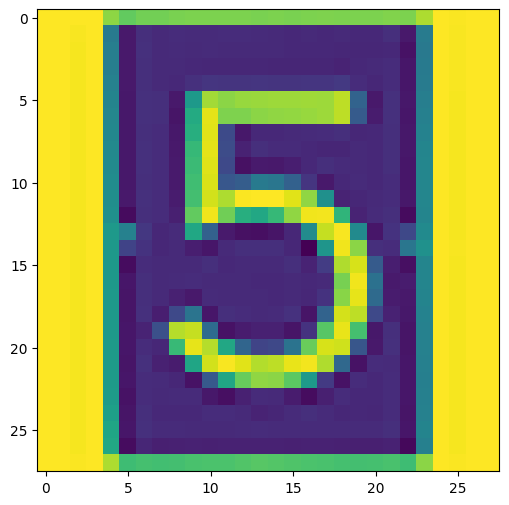

In [54]:
img_rows, img_cols = 28, 28
img = Image.fromarray(np.uint8(image)).convert('L')
img_gray = img.resize((img_rows, img_cols), Image.LANCZOS)

plt.imshow(img_gray)

arr = np.array(img_gray)
arr = arr.reshape((img_cols*img_rows))
arr = np.expand_dims(arr, axis=0)

With this out of the way we can pass the prepared image to the model and see if it is classified correctly.

In [55]:
prediction = model.predict(arr)
np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


np.int64(2)

## Fashion MNIST

The Fashion MNIST dataset is another commonly used image dataset which consists of 10 classes of fashion items:

0.  T-shirt
1.  Trouser
2.  Pullover
3.  Dress
4.  Coat
5.  Sandal
6.  Shirt
7.  Sneaker
8.  Bag
9.  Ankle boot

The images are again 28*28 and grayscale.

First we load the data and show a subset as an example.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


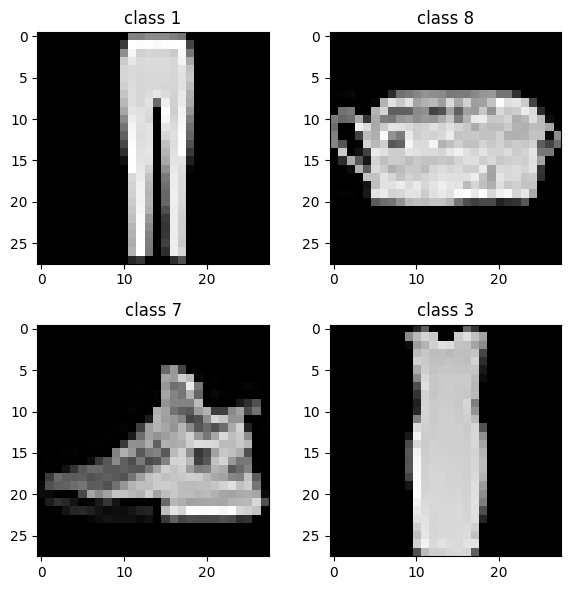

In [56]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


plt.rcParams['figure.figsize'] = (6,6) 

for i in range(4):
    plt.subplot(2,2,i+1)
    num = random.randint(0, len(X_train))
    plt.imshow(X_train[num], cmap='gray', interpolation='none')
    plt.title("class {}".format(y_train[num]))
    
plt.tight_layout()

Then we convert the images to 784 element floating point feature vectors.

In [58]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(X_train.shape)
print(X_test.shape)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train /= 255
X_test /= 255

(60000, 784)
(10000, 784)


The classes need to be One-hot encoded so the model can properly work with it. Number values that are not ordinal are not proper inputs for neural networks.

In [59]:
enc = OneHotEncoder(sparse_output=False)
enc.fit(y_train.reshape(-1, 1))
print(enc.categories_)
y_train_enc = enc.transform(y_train.reshape(-1,1))
y_test_enc = enc.transform(y_test.reshape(-1,1))

[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)]


Finally we can build the model as before, train it and evaluate the results.

In [60]:
feature_vector_shape = X_train.shape[1]
input_shape = (feature_vector_shape,)
num_classes = 10
loss_function_used = CategoricalCrossentropy(from_logits=False)

model = Sequential()
model.add(Input(input_shape))
model.add(Dense(12, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(8, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(num_classes, activation='softmax'))


model.compile(loss=loss_function_used, optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=['accuracy'])
history = model.fit(X_train, y_train_enc, epochs=25, batch_size=5, verbose=1, validation_split=0.2)

test_results = model.evaluate(X_test, y_test_enc, verbose=1)
print(f'Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]*100}%')

Epoch 1/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - accuracy: 0.7637 - loss: 0.6484 - val_accuracy: 0.8253 - val_loss: 0.4949
Epoch 2/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8360 - loss: 0.4629 - val_accuracy: 0.8299 - val_loss: 0.4659
Epoch 3/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.8469 - loss: 0.4282 - val_accuracy: 0.8453 - val_loss: 0.4326
Epoch 4/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8522 - loss: 0.4099 - val_accuracy: 0.8543 - val_loss: 0.4102
Epoch 5/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.8590 - loss: 0.3975 - val_accuracy: 0.8556 - val_loss: 0.4178
Epoch 6/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 64s 5ms/step - accuracy: 0.8600 - loss: 0.3906 - val_accuracy: 0.8553 - val_loss: 0.4194
Epoch 7/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 74s 4ms/step - accuracy: 0.8612 - loss: 0.3817 - val_accuracy: 0.8612 - val_loss: 0.3998
Epoch 8/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8649 - loss: 0

By using Sparse CCE we can keep the model labels as integers instead of needing to OH encode.

In [61]:
feature_vector_shape = X_train.shape[1]
input_shape = (feature_vector_shape,)
num_classes = 10
loss_function_used = SparseCategoricalCrossentropy(from_logits=False)

model = Sequential()
model.add(Dense(12, input_shape=input_shape, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(8, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss=loss_function_used, optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=25, batch_size=5, verbose=1, validation_split=0.2)

test_results = model.evaluate(X_test, y_test, verbose=1)
print(f'Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]*100}%')

Epoch 1/25


c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.7564 - loss: 0.6727 - val_accuracy: 0.8033 - val_loss: 0.5583
Epoch 2/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.8223 - loss: 0.5025 - val_accuracy: 0.8161 - val_loss: 0.5237
Epoch 3/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8352 - loss: 0.4685 - val_accuracy: 0.8311 - val_loss: 0.4846
Epoch 4/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8422 - loss: 0.4488 - val_accuracy: 0.8293 - val_loss: 0.4842
Epoch 5/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8457 - loss: 0.4339 - val_accuracy: 0.8447 - val_loss: 0.4407
Epoch 6/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8494 - loss: 0.4250 - val_accuracy: 0.8382 - val_loss: 0.4581
Epoch 7/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8511 - loss: 0.4169 - val_accuracy: 0.8434 - val_loss: 0.4564
Epoch 8/25
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8547 - loss: 0.4083 - val